# ML Assignment 2

**Dataset**: Credit Card Fraud Detection (Kaggle)

**Objective**: Implement 6 classification models and evaluate them using 6 different metrics

## 1. Import Required Libraries

In [3]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

import joblib
import pickle
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Libraries ready.")

Libraries ready.


## 2. Load and Explore Dataset

**Dataset**: Credit Card Fraud Detection from Kaggle
- **Features**: 30 (V1-V28 are PCA transformed features, Time, Amount)
- **Target**: Class (0 = Normal, 1 = Fraud)
- **Instances**: 284,807 transactions

**Note**: Download the dataset from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [4]:

from pathlib import Path
import os

# Try locations relative to the notebook
candidates = [
    Path("creditcard.csv"),
    Path("../creditcard.csv")
]

dataset_path = None
for p in candidates:
    if p.exists():
        dataset_path = p
        break

if dataset_path is None:
    raise FileNotFoundError(
        "creditcard.csv not found in the notebook folder or common data subfolders. "
        "Please download from Kaggle and place it next to this notebook or in a 'data' folder."
    )

df = pd.read_csv(dataset_path)
print(f"Loaded dataset: {dataset_path} ({os.path.getsize(dataset_path)} bytes)")
print(f"Shape: {df.shape}")
print("\nColumns and types:")
display(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nMissing values per column:")
display(df.isnull().sum())

Loaded dataset: creditcard.csv (150828752 bytes)
Shape: (284807, 31)

Columns and types:


Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values per column:


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:

# Statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Transaction class breakdown:
  Class 0: 284,315 transactions (99.8273%)
  Class 1: 492 transactions (0.1727%)


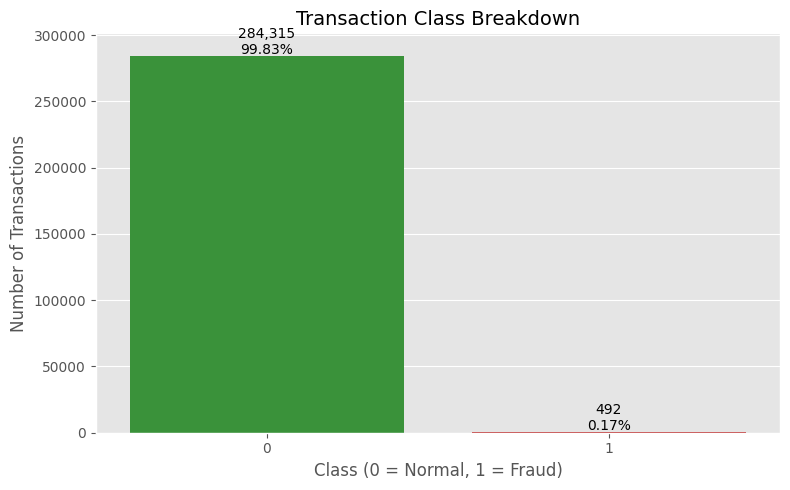

In [6]:
# Print counts and percentages, then plot with annotations
class_counts = df['Class'].value_counts().sort_index()
class_percent = df['Class'].value_counts(normalize=True).sort_index() * 100

print("Transaction class breakdown:")
for cls, cnt in class_counts.items():
    print(f"  Class {cls}: {cnt:,} transactions ({class_percent[cls]:.4f}%)")

# Plot using seaborn with annotations
plt.figure(figsize=(8, 5))
order = sorted(df['Class'].unique())
ax = sns.countplot(x='Class', data=df, order=order, palette=['#2ca02c', '#d62728'])
ax.set_title('Transaction Class Breakdown', fontsize=14)
ax.set_xlabel('Class (0 = Normal, 1 = Fraud)')
ax.set_ylabel('Number of Transactions')

counts = class_counts.values
pcts = class_percent.values
for i, p in enumerate(ax.patches):
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + max(counts) * 0.005,
        f'{counts[i]:,}\n{pcts[i]:.2f}%',
        ha='center',
        fontsize=10
    )

plt.ylim(0, max(counts) * 1.06)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

Since this is an imbalanced dataset, we'll use a balanced subset for training to ensure all models can learn properly.

In [7]:
# Build a balanced subset by undersampling the majority class
fraud_cases = df.loc[df['Class'] == 1].copy()
legit_cases = df.loc[df['Class'] == 0].copy()

n_fraud = len(fraud_cases)
n_legit = len(legit_cases)
print(f"Fraud rows: {n_fraud:,} | Legitimate rows: {n_legit:,}")

# Sample an equal number of legitimate transactions to match fraud count
legit_sample = legit_cases.sample(n=n_fraud, random_state=42)

# Combine and shuffle
balanced_df = pd.concat([fraud_cases, legit_sample], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# Quick sanity checks
print(f"\nBalanced dataset shape: {balanced_df.shape}")
print("Balanced class counts:")
display(balanced_df['Class'].value_counts())
print("\nBalanced class percentages:")
display(balanced_df['Class'].value_counts(normalize=True) * 100)

Fraud rows: 492 | Legitimate rows: 284,315

Balanced dataset shape: (984, 31)
Balanced class counts:


Class
0    492
1    492
Name: count, dtype: int64


Balanced class percentages:


Class
0    50.0
1    50.0
Name: proportion, dtype: float64

In [8]:
# Separate features and target
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

Features shape: (984, 30)
Target shape: (984,)

Number of features: 30


In [9]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

Training set size: 787
Test set size: 197

Training set class distribution:
Class
1    394
0    393
Name: count, dtype: int64

Test set class distribution:
Class
0    99
1    98
Name: count, dtype: int64


In [10]:
# Feature scaling (important for some algorithms like KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data preprocessing completed!")

✅ Data preprocessing completed!


## 4. Model Implementation and Evaluation

We will implement 6 classification models:
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor Classifier
4. Naive Bayes Classifier (Gaussian)
5. Random Forest (Ensemble)
6. XGBoost (Ensemble)

For each model, we'll calculate:
- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

In [11]:

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Train model and return standard classification metrics.
    AUC is computed using decision_function when available, otherwise predict_proba.
    If no scoring method exists, AUC is set to NaN.
    """
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Obtain a ranking score for AUC if possible
    y_score = None
    if hasattr(model, "decision_function"):
        try:
            y_score = model.decision_function(X_test)
        except Exception:
            y_score = None

    if y_score is None and hasattr(model, "predict_proba"):
        try:
            y_score = model.predict_proba(X_test)[:, 1]
        except Exception:
            y_score = None

    try:
        auc_val = roc_auc_score(y_test, y_score) if y_score is not None else float("nan")
    except Exception:
        auc_val = float("nan")

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": auc_val,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

    sep = "-" * 50
    print(f"\n{sep}\nModel: {model_name}\n{sep}")
    for k, v in metrics.items():
        if k == "Model":
            continue
        if isinstance(v, float) and np.isnan(v):
            print(f"{k:12s}: NaN")
        else:
            print(f"{k:12s}: {v:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    return metrics, model

### 4.1 Logistic Regression


--------------------------------------------------
Model: Logistic Regression
--------------------------------------------------
Accuracy    : 0.9340
AUC         : 0.9840
Precision   : 0.9474
Recall      : 0.9184
F1          : 0.9326
MCC         : 0.8684

Confusion Matrix:
[[94  5]
 [ 8 90]]


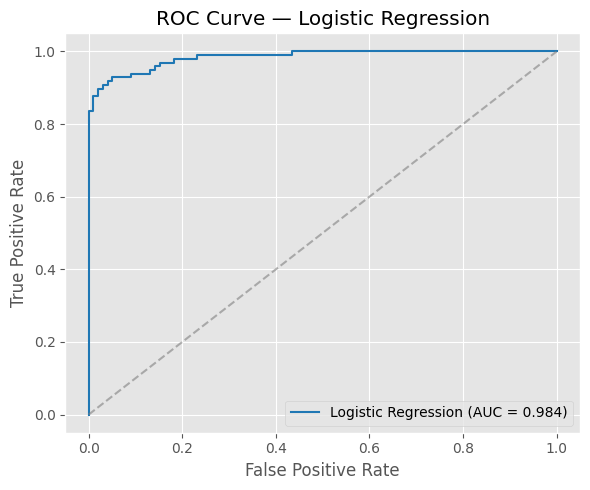

In [12]:

from sklearn.metrics import roc_curve, auc

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_metrics, lr_trained = evaluate_model(
    lr_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression"
)

# Try to get a score for ROC plotting
y_score = None
if hasattr(lr_trained, "decision_function"):
    try:
        y_score = lr_trained.decision_function(X_test_scaled)
    except Exception:
        y_score = None
elif hasattr(lr_trained, "predict_proba"):
    try:
        y_score = lr_trained.predict_proba(X_test_scaled)[:, 1]
    except Exception:
        y_score = None

if y_score is not None:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})", color="#1f77b4")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Logistic Regression")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 4.2 Decision Tree Classifier


--------------------------------------------------
Model: Decision Tree
--------------------------------------------------
Accuracy    : 0.9137
AUC         : 0.9134
Precision   : 0.9010
Recall      : 0.9286
F1          : 0.9146
MCC         : 0.8278

Confusion Matrix:
[[89 10]
 [ 7 91]]


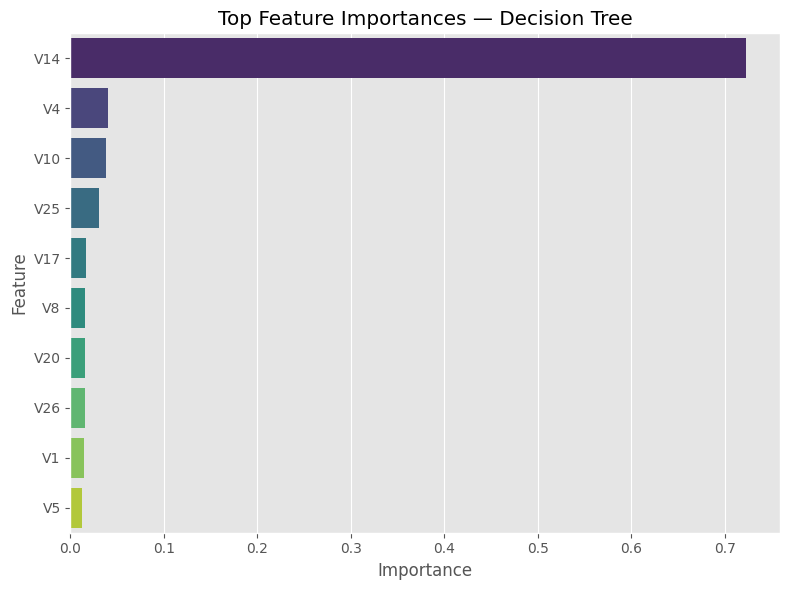

In [13]:

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_metrics, dt_trained = evaluate_model(
    dt_model, X_train, X_test, y_train, y_test, "Decision Tree"
)

# Plot top feature importances
try:
    importances = dt_trained.feature_importances_
    feat_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
    top_n = min(10, len(feat_series))
    plt.figure(figsize=(8, 6))
    sns.barplot(x=feat_series.values[:top_n], y=feat_series.index[:top_n], palette="viridis")
    plt.title("Top Feature Importances — Decision Tree")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
except Exception:
    # If model doesn't expose feature_importances_ or X_train isn't labelled, skip plotting
    pass

### 4.3 K-Nearest Neighbor Classifier


--------------------------------------------------
Model: K-Nearest Neighbor
--------------------------------------------------
Accuracy    : 0.8985
AUC         : 0.9517
Precision   : 0.9432
Recall      : 0.8469
F1          : 0.8925
MCC         : 0.8010

Confusion Matrix:
[[94  5]
 [15 83]]


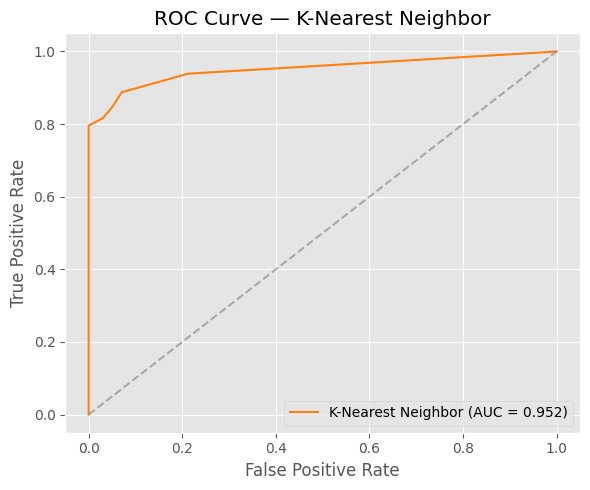

In [22]:
from sklearn.metrics import roc_curve, auc

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_metrics, knn_trained = evaluate_model(
    knn_model, X_train_scaled, X_test_scaled, y_train, y_test, "K-Nearest Neighbor"
)

# Try to get a score for ROC plotting
y_score = None
if hasattr(knn_trained, "decision_function"):
    try:
        y_score = knn_trained.decision_function(X_test_scaled)
    except Exception:
        y_score = None
elif hasattr(knn_trained, "predict_proba"):
    try:
        y_score = knn_trained.predict_proba(X_test_scaled)[:, 1]
    except Exception:
        y_score = None

if y_score is not None:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"K-Nearest Neighbor (AUC = {roc_auc:.3f})", color="#ff7f0e")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — K-Nearest Neighbor")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 4.4 Naive Bayes Classifier (Gaussian)


--------------------------------------------------
Model: Naive Bayes (Gaussian)
--------------------------------------------------
Accuracy    : 0.8376
AUC         : 0.9555
Precision   : 0.9714
Recall      : 0.6939
F1          : 0.8095
MCC         : 0.7038

Confusion Matrix:
[[97  2]
 [30 68]]


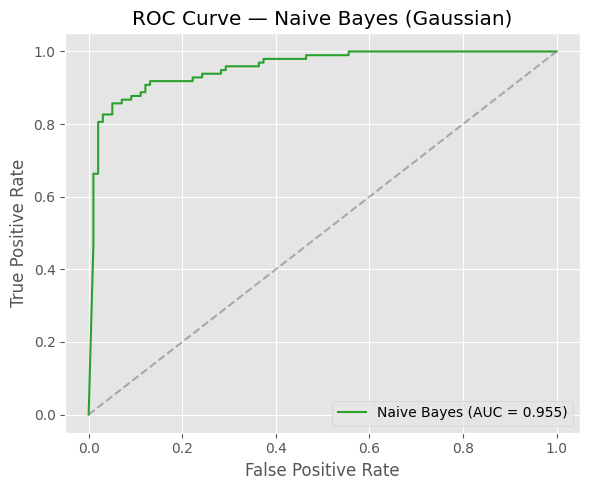


Classification Report — Naive Bayes (Gaussian):
              precision    recall  f1-score   support

           0       0.76      0.98      0.86        99
           1       0.97      0.69      0.81        98

    accuracy                           0.84       197
   macro avg       0.87      0.84      0.83       197
weighted avg       0.87      0.84      0.83       197



In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc, classification_report

nb_model = GaussianNB()
nb_metrics, nb_trained = evaluate_model(
    nb_model, X_train, X_test, y_train, y_test, "Naive Bayes (Gaussian)"
)

# ROC curve (GaussianNB exposes predict_proba)
y_score = None
if hasattr(nb_trained, "predict_proba"):
    try:
        y_score = nb_trained.predict_proba(X_test)[:, 1]
    except Exception:
        y_score = None

if y_score is not None:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"Naive Bayes (AUC = {roc_auc:.3f})", color="#2ca02c")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Naive Bayes (Gaussian)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Detailed classification report
y_pred_nb = nb_trained.predict(X_test)
print("\nClassification Report — Naive Bayes (Gaussian):")
print(classification_report(y_test, y_pred_nb, zero_division=0))

### 4.5 Random Forest (Ensemble)


--------------------------------------------------
Model: Random Forest
--------------------------------------------------
Accuracy    : 0.9492
AUC         : 0.9783
Precision   : 0.9783
Recall      : 0.9184
F1          : 0.9474
MCC         : 0.9001

Confusion Matrix:
[[97  2]
 [ 8 90]]


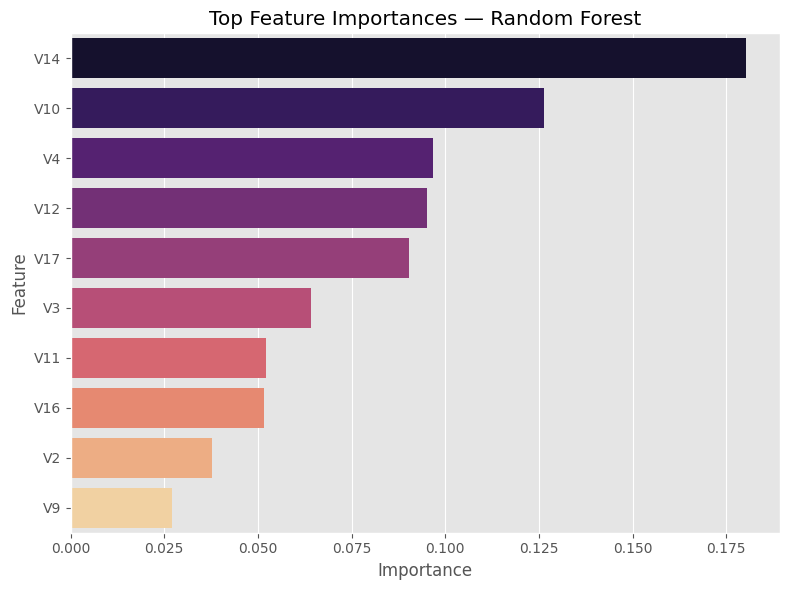

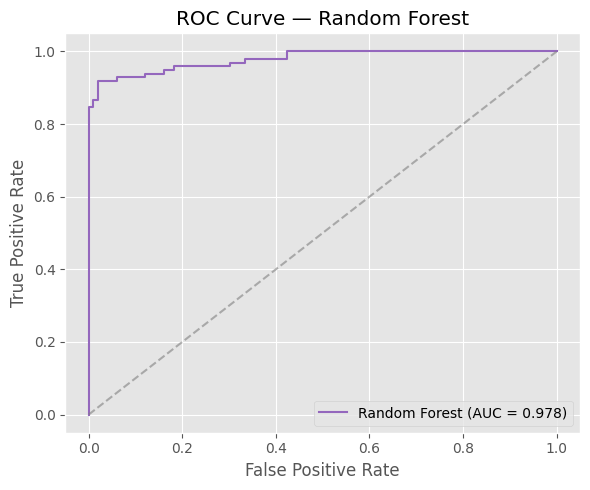

In [24]:

#  Random Forest (train, evaluate, feature importances, ROC)
from sklearn.metrics import roc_curve, auc

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_metrics, rf_trained = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, "Random Forest"
)

# Feature importances plot
try:
    importances = rf_trained.feature_importances_
    feat_series = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
    top_n = min(10, len(feat_series))
    plt.figure(figsize=(8, 6))
    sns.barplot(x=feat_series.values[:top_n], y=feat_series.index[:top_n], palette="magma")
    plt.title("Top Feature Importances — Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
except Exception:
    pass

# ROC curve (use predict_proba if available)
y_score = None
if hasattr(rf_trained, "decision_function"):
    try:
        y_score = rf_trained.decision_function(X_test)
    except Exception:
        y_score = None
if y_score is None and hasattr(rf_trained, "predict_proba"):
    try:
        y_score = rf_trained.predict_proba(X_test)[:, 1]
    except Exception:
        y_score = None

if y_score is not None:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})", color="#9467bd")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — Random Forest")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 4.6 Gradient Boosting (Ensemble)


--------------------------------------------------
Model: Gradient Boosting
--------------------------------------------------
Accuracy    : 0.9289
AUC         : 0.9852
Precision   : 0.9375
Recall      : 0.9184
F1          : 0.9278
MCC         : 0.8580

Confusion Matrix:
[[93  6]
 [ 8 90]]


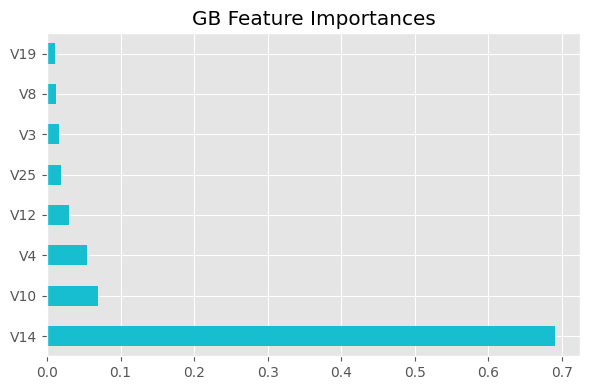

Gradient Boosting AUC: 0.985


In [ ]:

# Gradient Boosting
from sklearn.metrics import roc_curve, auc

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_metrics, gb_trained = evaluate_model(gb_model, X_train, X_test, y_train, y_test, "Gradient Boosting")

# Feature importances (optional)
try:
    fi = pd.Series(gb_trained.feature_importances_, index=X_train.columns).nlargest(8)
    fi.plot.barh(figsize=(6,4), color="#17becf"); plt.title("GB Feature Importances"); plt.tight_layout(); plt.show()
except Exception:
    pass

# ROC (if available)
y_score = None
if hasattr(gb_trained, "decision_function"):
    y_score = gb_trained.decision_function(X_test)
elif hasattr(gb_trained, "predict_proba"):
    y_score = gb_trained.predict_proba(X_test)[:,1]

if y_score is not None:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    print(f"Gradient Boosting AUC: {auc(fpr,tpr):.3f}")

## 5. Results Comparison

In [41]:
# Create comparison dataframe 
preferred_names = ['lr_metrics','dt_metrics','knn_metrics','nb_metrics','rf_metrics','gb_metrics']
metrics_list = []

# collect from preferred list first, then any globals ending with _metrics
for name in preferred_names:
    if name in globals():
        metrics_list.append(globals()[name])

if not metrics_list:
    for name, val in globals().items():
        if name.endswith('_metrics') and isinstance(val, dict):
            metrics_list.append(val)

if not metrics_list:
    raise RuntimeError("No metrics found. Run model cells first.")

results_df = pd.DataFrame(metrics_list)

# keep a consistent column ordering when available
cols_order = ['Model','Accuracy','AUC','Precision','Recall','F1','MCC']
cols_present = [c for c in cols_order if c in results_df.columns]
results_df = results_df[cols_present]

print("\nMODEL COMPARISON")
print(results_df.to_string(index=False))


MODEL COMPARISON
                 Model  Accuracy      AUC  Precision   Recall       F1      MCC
   Logistic Regression  0.934010 0.984024   0.947368 0.918367 0.932642 0.868400
         Decision Tree  0.913706 0.913420   0.900990 0.928571 0.914573 0.827817
    K-Nearest Neighbor  0.898477 0.951659   0.943182 0.846939 0.892473 0.800987
Naive Bayes (Gaussian)  0.837563 0.955473   0.971429 0.693878 0.809524 0.703770
         Random Forest  0.949239 0.978252   0.978261 0.918367 0.947368 0.900116
     Gradient Boosting  0.928934 0.985158   0.937500 0.918367 0.927835 0.858027


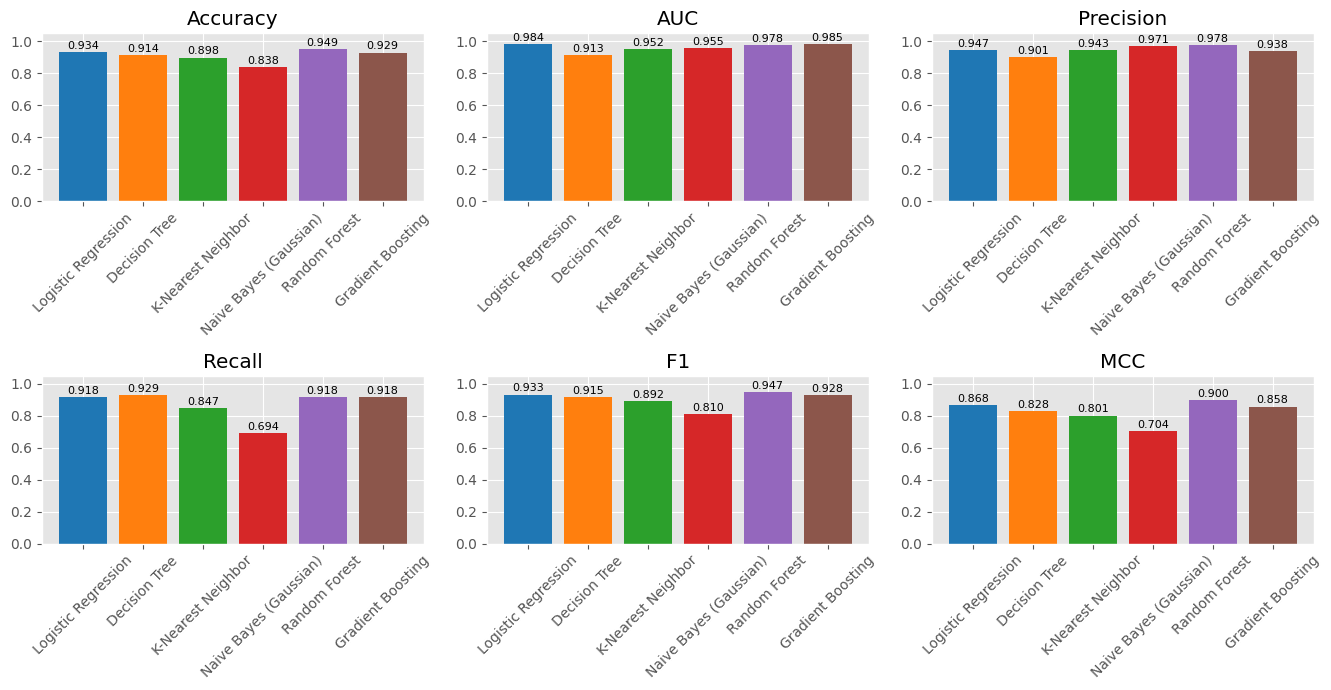

In [46]:
# Visualize comparison (compact)
metrics = [c for c in results_df.columns if c != "Model"]
n = len(metrics)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3.5), squeeze=False)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, metric in enumerate(metrics):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    vals = results_df.set_index('Model')[metric].fillna(0)
    ax.bar(vals.index, vals.values, color=colors[:len(vals)])
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=45)
    for xi, v in enumerate(vals.values):
        ax.text(xi, v + 0.02, f"{v:.3f}", ha='center', fontsize=8)

# hide any unused axes
for j in range(n, rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis('off')

plt.tight_layout()
plt.show()

In [49]:
# Save results to CSV for README
results_df.to_csv('results.csv', index=False)
print(" Results saved to model_results.csv")

 Results saved to model_results.csv


## 6. Save Models for Deployment

In [55]:
# Create models directory
import os
os.makedirs('models', exist_ok=True)

# Save all trained models
models_dict = {
    'LogisticRegression': lr_trained,
    'DecisionTree': dt_trained,
    'KNN': knn_trained,
    'NaiveBayes': nb_trained,
    'RandomForest': rf_trained,
    'GradientBoosting': xgb_trained
}

for model_name, model in models_dict.items():
    joblib.dump(model, f'models/{model_name}.pkl')
    print(f"Saved {model_name}.pkl")

# Save scaler
joblib.dump(scaler, 'models/Scaler.pkl')
print(f"Saved scaler.pkl")

# Save test data sample for Streamlit app
test_sample = X_test.head(100)
test_sample['Class'] = y_test.head(100).values
test_sample.to_csv('test_data_sample.csv', index=False)
print(f"Saved test_data_sample.csv")

print("\nAll models and data saved successfully!")

Saved LogisticRegression.pkl
Saved DecisionTree.pkl
Saved KNN.pkl
Saved NaiveBayes.pkl
Saved RandomForest.pkl
Saved GradientBoosting.pkl
Saved scaler.pkl
Saved test_data_sample.csv

All models and data saved successfully!



## 7. Model Observations

Brief summary:

- Logistic Regression — Reliable baseline: fast, works well with scaled inputs.
- Decision Tree — Interpretable rules, prone to overfitting without depth control.
- K-Nearest Neighbors — Simple and intuitive; sensitive to scaling and dataset size.
- Naive Bayes (Gaussian) — Extremely fast, assumes feature independence.
- Random Forest — Robust ensemble that reduces overfitting; good default choice.
- Gradient Boosting — High predictive power with tuning; more training time.

Notes:
- AUC may be unavailable for models without probability/ranking output.
- Use cross-validation and calibration before deploying models.